# 08 Full Paper Reproduction

Creates the principal tables and figures for the Results section from all attached records.

In [1]:
from pathlib import Path
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
ROOT=Path.cwd().parent if Path.cwd().name=="notebooks" else Path.cwd()
sys.path.insert(0,str(ROOT/"src"))
from dds_analysis import *
DATA=ROOT/"data"; OUT=ROOT/"outputs"; OUT.mkdir(exist_ok=True)
df=load_seqacs(DATA); validate_schema(df)
print(f"Loaded {len(df):,} rows and {len(df.columns)} columns")


Loaded 520,000 rows and 37 columns


In [2]:
overall=df[["ddsr_qkd_only","ddsr_pqc_only","ddsr_static_hybrid","ddsr_seqacs"]].mean().rename("mean_DDSR")
overall.to_csv(OUT/"paper_table_main_ddsr.csv"); display(overall)

ddsr_qkd_only         0.230152
ddsr_pqc_only         0.242196
ddsr_static_hybrid    0.213153
ddsr_seqacs           0.159629
Name: mean_DDSR, dtype: float64

In [3]:
scenario_summary(df).to_csv(OUT/"paper_table_scenario_summary.csv")
print("Saved scenario summary.")

Saved scenario summary.


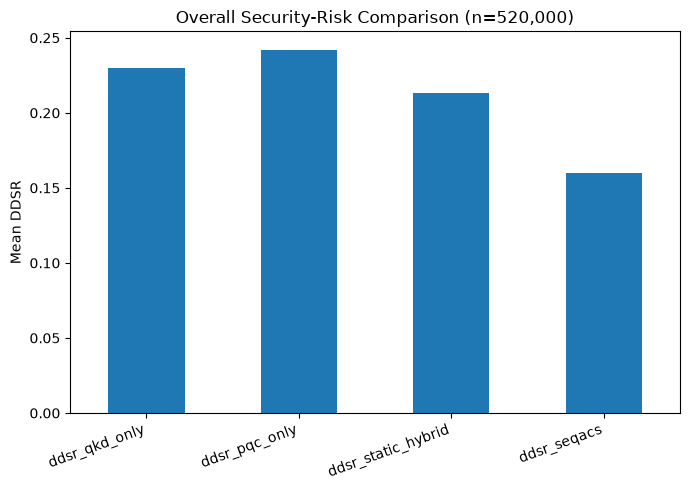

In [4]:
plt.figure(figsize=(7,5)); overall.plot(kind="bar")
plt.ylabel("Mean DDSR"); plt.title("Overall Security-Risk Comparison (n={:,})".format(len(df)))
plt.xticks(rotation=20,ha="right"); plt.tight_layout(); plt.savefig(OUT/"paper_fig_overall_ddsr.png",dpi=300); plt.show()

In [5]:
manifest={"rows":len(df),"files":5,"synthetic_dataset":True,
"theorem_note":"Dataset supports numerical illustration/consistency checks; formal proof remains assumption-dependent.",
"risk_product":"R_H = L_Q * L_C","advantage_bound":"Adv_DDS <= Adv_QKD * Adv_PQC"}
(OUT/"reproducibility_manifest.json").write_text(json.dumps(manifest,indent=2))

NameError: name 'json' is not defined